# Data Preprocessing and Modeling

## Objective

The objective of this section is to prepare the dataset for machine learning models and build predictive models for customer churn.

In [258]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [204]:
train_df = pd.read_csv('../data/processed/train.csv')
test_df = pd.read_csv('../data/processed/test.csv')

## Converting Churn Feature into Numeric

In this section, the target variable is prepared for machine learning by converting it into a numerical format.

In [205]:
train_df['Churn'] = train_df['Churn'].map({'Yes': 1, 'No': 0})
test_df['Churn'] = test_df['Churn'].map({'Yes': 1, 'No': 0})

## Feature and Target Separation

The dataset is divivded into features `X` and target variable `y`.

In [206]:
X_train = train_df.drop('Churn', axis = 1)
X_test = test_df.drop('Churn', axis = 1)
y_train = train_df['Churn']
y_test = test_df['Churn']

In [207]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5634, 19) (1409, 19) (5634,) (1409,)


## Preprocessing Pipeline

Categorical and numerical features require different preprocessing steps.

- Numerical features are scaled using `StandardScaler`.
- Categorical features are transformed into numerical values using `OneHotEncoder`.

A `ColumnTransformer` is used to apply each transformation to the appropriate columns.

In [208]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [209]:
categorical_features = train_df.columns.tolist()
for num in numerical_features:
    categorical_features.remove(num)
categorical_features.remove('SeniorCitizen')
categorical_features.remove('Churn')

In [210]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [211]:
binary_features = ['SeniorCitizen']

### Build the Preprocessing Pipelines

In this section we perform multiple standard preprocessing functions.

For numerical features we use Standard Scaler and for categorical features One Hot Encoder is used.

Binary features dont need any transformations so they get passed through.

In [212]:
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

In [213]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
        ('binary', 'passthrough', binary_features)
    ]
)

## Baseline Model: Logistic Regression

A Logistic Regression model is used as the baseline classifier. It provides a simple and interpretable benchmark for evaluating more complex models.

In [214]:
lr_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42))
    ]
)

In [215]:
lr_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Check for Overfitting and Underfitting

In order to make sure our model did not overfit or underfit, we need to compare the accuracy on train data with test data.

If the model performs well on train data but poorly on test data it overfitted, but if the model does not perform well on the train data then it underfitted.

Note that since the target value disttibution is imbalanced accuracy alone is not a fair measure to evaluate the model and we need to use other methods such as recall, precision and f1-score.

In [216]:
print('Accuracy on train data:', lr_model.score(X_train, y_train))
print('Accuracy on test data:', lr_model.score(X_test, y_test))

Accuracy on train data: 0.8059992900248492
Accuracy on test data: 0.8055358410220014


### Model Evaluation

The performance of the model is evaluated using multiple classification metrics, including accuracy, precision, recall, F1-score and confusion matrix.

In [217]:
y_pred = lr_model.predict(X_test)

In [218]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [219]:
cm = confusion_matrix(y_test, y_pred)
confusion_matrix_report = pd.DataFrame(
   cm,
   index=['Actual Negative', 'Actual Positive'],
   columns=['Predicted Negative', 'Predicted Positive']
)
confusion_matrix_report

,Predicted Negative,Predicted Positive
Actual Negative,926,109
Actual Positive,165,209


### Model Performance Summary

The Logistic Regression model achieved an overall accuaracy of **81%**.

The model performs well in identifying customers who stay with the company. However, its performance on the churn class is weaker with a recall of **56%**. This indicates that a considerable number of churned customers are not correctly identified.

### ROC Curve and AUC

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the True Positive Rate and the False Positive Rate at different classification thresholds.

The Area Under the Curve (AUC) summarizes the model's ability to distinguish between the two classes. A higher AUC indicates better classification performance.

In [220]:
y_prob = lr_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
auc

0.8419566509080574

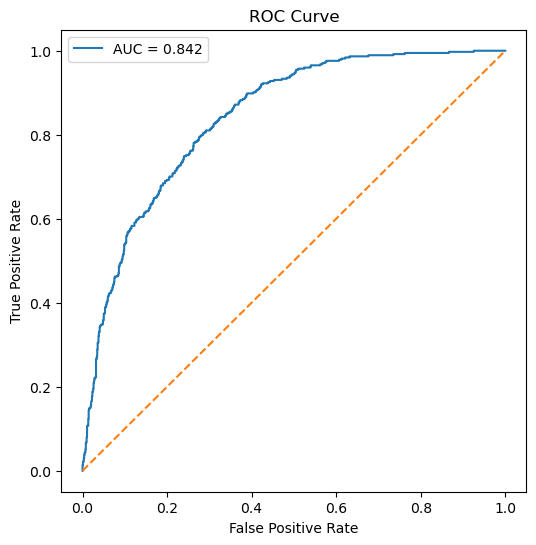

In [221]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

**Insight**

The Logistic Regression model achieved an AUC score of 0.842, indicating good discrimination ability between churned and retained customers.

The ROC curve shows that the model performs considerably better than random classification and can effectively distinguish between the two classes.

## Decision Tree Classifier

A Decision Tree Classifier is trained to capture nonlinear relationships between customer characteristics and churn behavior.

The model is evaluated using same metrics as the baseline model for comparision.

In [222]:
dt_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]
)

In [223]:
dt_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [224]:
print('Accuracy on train data:', dt_model.score(X_train, y_train))
print('Accuracy on test data:', dt_model.score(X_test, y_test))

Accuracy on train data: 0.9980475683351083
Accuracy on test data: 0.7281760113555713


**Overfittng Alert** 

The accuarcy of decision tree model on training data is very high. It might mean the model learned the details of training data instead of finding the pattern.

In [225]:
y_pred = dt_model.predict(X_test)

In [226]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.49      0.50      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.65      1409
weighted avg       0.73      0.73      0.73      1409



In [227]:
cm = confusion_matrix(y_test, y_pred)
confusion_matrix_report = pd.DataFrame(
   cm,
   index=['Actual Negative', 'Actual Positive'],
   columns=['Predicted Negative', 'Predicted Positive']
)
confusion_matrix_report

,Predicted Negative,Predicted Positive
Actual Negative,839,196
Actual Positive,187,187


In [228]:
y_prob = dt_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
auc

0.6550724637681159

### Decision Tree Results

The default Decision Tree classifier achieved lower performance than the baseline Logistic Regression model.

It produced lower precision, recall, F1-score and overall accuracy. This suggests that the default Decision Tree was not able to generalize well on the test data.

Further hyperparameter tuning may improve its performance.

## Random Forest Classifier

A random Forest classifier is trained to improve prediction performance by combining multiple decision trees.

Compared to a single Decision Tree, Random Forest generally provides better generalization and reduces the risk of overfitting.

In [229]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ]
)

In [230]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [231]:
print('Accuracy on train data:', rf_model.score(X_train, y_train))
print('Accuracy on test data:', rf_model.score(X_test, y_test))

Accuracy on train data: 0.9980475683351083
Accuracy on test data: 0.7856635911994322


**Overfittng Alert** 

The accuarcy of random forest model on training data is very high. It means the model learned the details of training data instead of finding the pattern. This indicates that tree-based model tend to overfit so the regularization and hyperparameter tuning is necessary.

In [232]:
y_pred = rf_model.predict(X_test)

In [233]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



In [234]:
cm = confusion_matrix(y_test, y_pred)
confusion_matrix_report = pd.DataFrame(
   cm,
   index=['Actual Negative', 'Actual Positive'],
   columns=['Predicted Negative', 'Predicted Positive']
)
confusion_matrix_report

,Predicted Negative,Predicted Positive
Actual Negative,925,110
Actual Positive,192,182


In [235]:
y_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
auc

0.8186907437546824

### Random Forest Results

The Random Forest model outperformed the single Decision Tree but did not surpass the baeline Logistic Regression model.

Although the model achieved good performance in identifying non-churn customers, its recall for the churn class remained relatively low. This indicates that a considerable number of churned customers were still misclassified.

Further improvement may be achieved through hyperparameter tuning and class balancing.


## XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is an ensemble learning algorithm that builds trees sequentially, where each new tree attempts to correct the errors made by the previous ones.

It is widely used for structured tabular data due to its strong performance and robustness.

In [236]:
xgb_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
    ]
)

In [237]:
xgb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [238]:
print('Accuracy on train data:', xgb_model.score(X_train, y_train))
print('Accuracy on test data:', xgb_model.score(X_test, y_test))

Accuracy on train data: 0.9412495562655308
Accuracy on test data: 0.7764371894960965


In [239]:
y_pred = xgb_model.predict(X_test)

In [240]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.59      0.52      0.55       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [241]:
cm = confusion_matrix(y_test, y_pred)
confusion_matrix_report = pd.DataFrame(
   cm,
   index=['Actual Negative', 'Actual Positive'],
   columns=['Predicted Negative', 'Predicted Positive']
)
confusion_matrix_report

,Predicted Negative,Predicted Positive
Actual Negative,900,135
Actual Positive,180,194


In [242]:
y_prob = xgb_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
auc

0.820461649745537

### XGBoost Results

The XGBoost classifier achieved better performance than a single Decision Tree and Random Forest model but did not outperform Logistic Regression.

The model showed moderate peeformance in identifying churned customers. Further hyperparameter tuning may improve its predicitve ability.

## Model Comparison

Different classification models were evaluated using the same preprocessing pipeline.

The models were compared based on accuarcy, precision, recall and F1-score, with special focus on churn class.

In [243]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [0.81, 0.73, 0.79, 0.78],
    'Precision (Churn)': [0.66, 0.49, 0.62, 0.59],
    'Recall (Churn)': [0.56, 0.50, 0.49, 0.52],
    'F1-Score': [0.60, 0.49, 0.55, 0.55],
    'False Negative Count': [165, 187, 192, 180],
    'AUC': [84, 65, 81, 82]
})
model_results

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-Score,False Negative Count,AUC
0,Logistic Regression,0.81,0.66,0.56,0.60,165,84
1,Decision Tree,0.73,0.49,0.50,0.49,187,65
2,Random Forest,0.79,0.62,0.49,0.55,192,81
3,XGBoost,0.78,0.59,0.52,0.55,180,82


In [244]:
model_results.sort_values(by='Recall (Churn)', ascending=False)

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-Score,False Negative Count,AUC
0,Logistic Regression,0.81,0.66,0.56,0.60,165,84
3,XGBoost,0.78,0.59,0.52,0.55,180,82
1,Decision Tree,0.73,0.49,0.50,0.49,187,65
2,Random Forest,0.79,0.62,0.49,0.55,192,81


## Hyperparameter Tuning

Hyperparameter tuning will be used for the best performing models which are Logistic Regression and XGBoost.

GridSearchCV is used to optimize the hyperparameters and improve the model performance.

### Logistic Regeression 

In [245]:
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear'],
    'classifier__class_weight': [None, 'balanced']
}

In [256]:
grid_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid_lr,
    cv=5,
    scoring='recall'
)

In [247]:
grid_lr.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...), ...]"


In [248]:
grid_lr.best_params_

{'classifier__C': 1,
 'classifier__class_weight': 'balanced',
 'classifier__penalty': 'l1',
 'classifier__solver': 'liblinear'}

In [249]:
best_lr_model = grid_lr.best_estimator_

In [250]:
print('Accuracy on train data:', best_lr_model.score(X_train, y_train))
print('Accuracy on test data:', best_lr_model.score(X_test, y_test))

Accuracy on train data: 0.7527511537096202
Accuracy on test data: 0.7381121362668559


In [251]:
y_pred = best_lr_model.predict(X_test)

In [252]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [253]:
cm = confusion_matrix(y_test, y_pred)
confusion_matrix_report = pd.DataFrame(
   cm,
   index=['Actual Negative', 'Actual Positive'],
   columns=['Predicted Negative', 'Predicted Positive']
)
confusion_matrix_report

,Predicted Negative,Predicted Positive
Actual Negative,745,290
Actual Positive,79,295


In [281]:
y_prob = best_lr_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
auc

0.8419695678007699

### XGBoost

In [282]:
param_grid_xgb = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0],
    'classifier__min_child_weight': [1, 3, 5],
}

In [301]:
grid_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid_xgb,
    n_iter=50,
    cv=5,
    scoring='recall',
    random_state=42
)

In [293]:
grid_xgb.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__min_child_weight': [1, 3, ...], ...}"
,n_iter,50
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [294]:
grid_xgb.best_params_

{'classifier__subsample': 0.8,
 'classifier__n_estimators': 200,
 'classifier__min_child_weight': 5,
 'classifier__max_depth': 3,
 'classifier__learning_rate': 0.05,
 'classifier__colsample_bytree': 0.8}

In [295]:
best_xgb_model = grid_xgb.best_estimator_

In [296]:
print('Accuracy on train data:', best_xgb_model.score(X_train, y_train))
print('Accuracy on test data:', best_xgb_model.score(X_test, y_test))

Accuracy on train data: 0.8194888178913738
Accuracy on test data: 0.8062455642299503


In [297]:
y_pred = best_xgb_model.predict(X_test)

In [298]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [299]:
cm = confusion_matrix(y_test, y_pred)
confusion_matrix_report = pd.DataFrame(
   cm,
   index=['Actual Negative', 'Actual Positive'],
   columns=['Predicted Negative', 'Predicted Positive']
)
confusion_matrix_report

,Predicted Negative,Predicted Positive
Actual Negative,937,98
Actual Positive,175,199


In [300]:
y_prob = best_xgb_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
auc

0.8485003487561033

## Tuned Model Comparison

After hyperparameter tuning, both Logistic Regression and XGBoost showed improved performances in detecting churn customers.

Logistic Regression achieved a much higher recall, while XGBoost provided slightly better accuracy and precision.

However, Logistic Regression achieved higher f1-score as well.

In [302]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Logistic Regression Tuned',
        'XGBoost',
        'XGBoost Tuned'
    ],
    'Accuracy': [0.81, 0.74, 0.78, 0.81],
    'Precision (Churn)': [0.66, 0.5, 0.59, 0.67],
    'Recall (Churn)': [0.56, 0.79, 0.52, 0.53],
    'F1-Score': [0.60, 0.62, 0.55, 0.59],
    'False Negative Count': [165, 79, 180, 175],
    'AUC': [84, 84, 82, 84]
})
model_results

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-Score,False Negative Count,AUC
0,Logistic Regression,0.81,0.66,0.56,0.60,165,84
1,Logistic Regression Tuned,0.74,0.50,0.79,0.62,79,84
2,XGBoost,0.78,0.59,0.52,0.55,180,82
3,XGBoost Tuned,0.81,0.67,0.53,0.59,175,84


## Logistic Regression Feature Coefficients

Feature Coefficients show which customer characteristics have the most influence on churn prediction.

A positive coefficient indicates that the higher value of the feature increases the probability of churn and negative coefficient shows the reverse.

In [303]:
feature_names = best_lr_model.named_steps['preprocessor'].get_feature_names_out()
coefs = best_lr_model.named_steps['classifier'].coef_[0]

In [307]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs,
    'Abs_Coefficient': abs(coefs)
})
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)
coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
0,num__tenure,-1.144707,1.144707
37,cat__Contract_Two year,-0.955942,0.955942
30,cat__StreamingTV_No internet service,-0.656528,0.656528
14,cat__InternetService_DSL,-0.585845,0.585845
2,num__TotalCharges,0.475282,0.475282
35,cat__Contract_Month-to-month,0.473306,0.473306
19,cat__OnlineSecurity_Yes,-0.384478,0.384478
26,cat__TechSupport_No,0.354138,0.354138
42,cat__PaymentMethod_Electronic check,0.353622,0.353622
38,cat__PaperlessBilling_No,-0.337688,0.337688


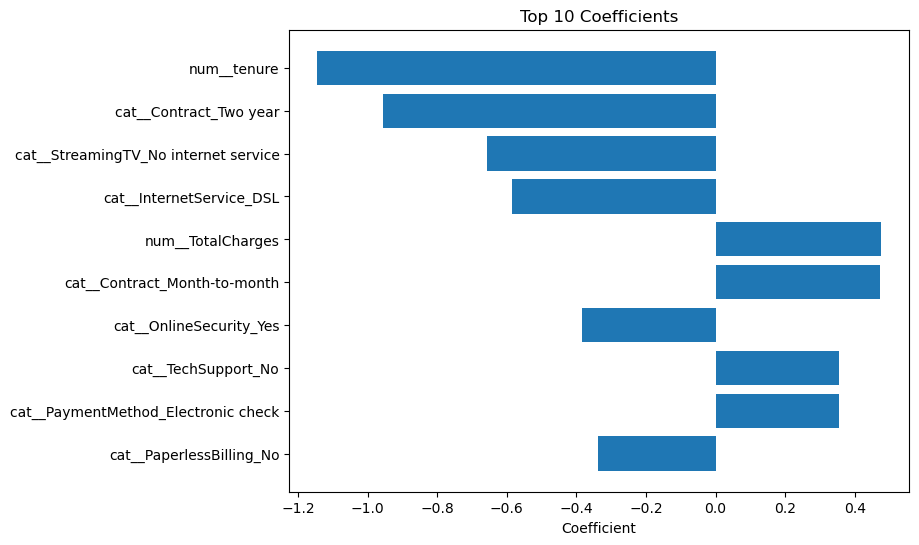

In [308]:
top10 = coef_df.head(10)
plt.figure(figsize=(8, 6))
plt.barh(top10['Feature'], top10['Coefficient'])
plt.title('Top 10 Coefficients')
plt.xlabel('Coefficient')
plt.gca().invert_yaxis()
plt.show()

### Insight

The features shown above have the most influence on customer churn prediction.

`Tenure` feature with a negative coefficient indicates that the less tenure a customer has the more likely it is to churn. Customers with longer tenure are less likely to churn, indicating that customer loyalty increases over time.

`Contract_Two_year` feature with a negative coefficient indicates that the long-term contract results in less churned customers. While the customers with monthly contracts are more likely to churn. This suggests that contract duration plays a significant role in customer retention.

## XGBoost Feature Importance

Feature importance is used to identify which customer characteristics have the greatest influence on churn prediction.

Understanding the most important features can provide valuable business insights and help organizations develop effective customer retention strategies.

In [309]:
feature_names = best_xgb_model.named_steps['preprocessor'].get_feature_names_out()
importance = best_xgb_model.named_steps['classifier'].feature_importances_

In [310]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
feature_importance.head(10)

,Feature,Importance
35,cat__Contract_Month-to-month,0.358319
17,cat__OnlineSecurity_No,0.100316
15,cat__InternetService_Fiber optic,0.085375
26,cat__TechSupport_No,0.053901
14,cat__InternetService_DSL,0.040023
42,cat__PaymentMethod_Electronic check,0.036851
37,cat__Contract_Two year,0.030727
16,cat__InternetService_No,0.026582
0,num__tenure,0.022803
36,cat__Contract_One year,0.020033


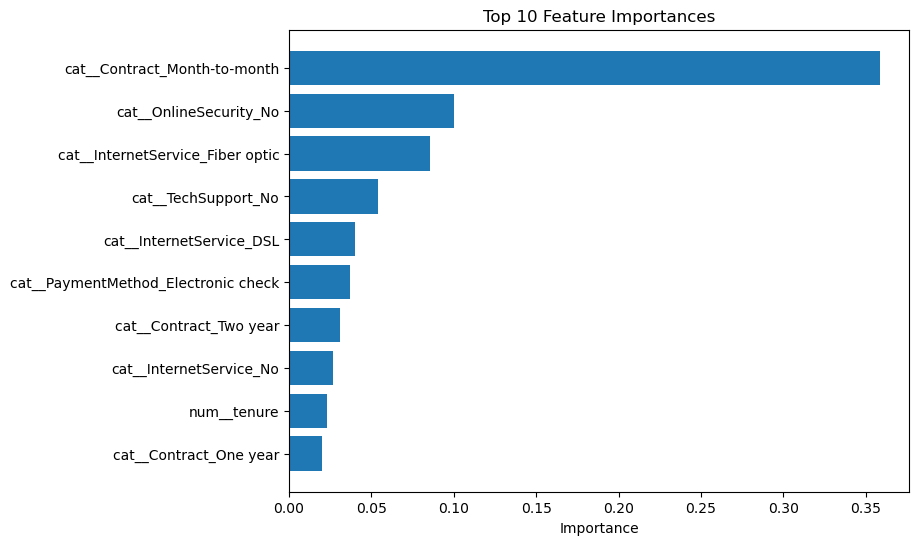

In [311]:
top10 = feature_importance.head(10)
plt.figure(figsize=(8, 6))
plt.barh(top10['Feature'], top10['Importance'])
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

### Insight

Unlike Logostic Regression Model, the month-to-month contract is detected as the most effiective feature.

# Conclusion

This project explored customer churn prediction using multiple machine learning models including Logistic Regression, Decision Tree, Random Forest and XGBoost.

After data preprocessing, building models and model evaluation, Logistic Regression and XGBoost achieved the best overall performance.
Hyperparameter tuning further improved the models, particularly in identifying churned customers.

The analysis also revealed that customer tenure and contract type were the most influential factors affecting churn. Customers with longer tenure and long-term contracts were less likely to leave, while customers with month-to-month contracts had a higher risk of churn.

These findings can help businesses identify customers at risk and develop targeted retention strategies to reduce customer churn.